# Loan Approval Classification

## Loading Library and Data

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import *

import keras
from keras import layers
from keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_og = pd.read_csv("../dataset/loan_data.csv")
df_og.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Basic Information

In [3]:
df_og.shape

(45000, 14)

Our dataset has 45000 Rows and 14 columns

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

Our dataset has 5 object column and the rest are numerical columns, but our target column has been identified as number even though it is a categorical column.

In [5]:
df_og.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
numerical_cols = df_og.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_og.select_dtypes(include=["object"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='str')
categorical cols: Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')


## Statistics of the data

In [7]:
df_og.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### Conclusion:

- The middle 50% of individuals are between 24 and 30 years old. However, the maximum age of 144 suggests the presence of data entry errors.
- Employment experience ranges between 1 and 8 years for the middle 50% of individuals. The maximum value of 125 years indicates outliers that should be handled - before modeling.
- These extreme values suggest data quality issues and should be cleaned to prevent negative impact on model performance.
- The middle 50% of loan amounts fall between 5,000 and 12,237.
- Loan interest rates range from 5.42% to 20%, with mean (11.00%) and median (11.01%) being nearly identical, indicating a symmetric distribution.
- Borrowers request loans that are typically between 7% and 19% of their income (middle 50%).
- Credit history length for the middle 50% of individuals lies between 3 and 8 years.
- Income for the middle 50% of borrowers ranges from approximately 47,200 to 95,789.
- Credit scores for the middle 50% fall between 601 and 670.
- Approximately 22% of borrowers defaulted, indicating class imbalance. Therefore, stratified splitting (stratify=y) should be used during train-test split.

### Visualisation

In [8]:
def plot_df(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns

    # ---------- CATEGORICAL ----------
    if len(cat_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(cat_cols) / n_cols)

        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(cat_cols, 1):
            plt.subplot(n_rows, n_cols, i)

            values = df[col].value_counts()
            top = values.head(5)

            if len(values) > 5:
                top["Others"] = values[5:].sum()

            plt.pie(top, labels=top.index, autopct="%1.1f%%", startangle=90)
            plt.title(f"Pie Chart - {col}")

        plt.suptitle("Categorical Columns - Pie Chart", y=1.02)
        plt.tight_layout()
        plt.show()

    # ---------- NUMERICAL BOXPLOTS ----------
    if len(num_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(num_cols) / n_cols)

        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(num_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.boxplot(x=df[col])
            plt.title(f"Boxplot - {col}")

        plt.suptitle("Numerical Columns - Boxplot", y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------- HISTOGRAMS ----------
        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(num_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.histplot(df[col].dropna(), kde=True, bins=30)
            plt.axvline(df[col].mean(), linestyle="dashed", linewidth=1)
            plt.title(f"Histplot - {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        plt.suptitle("Numerical Columns - Histplot", y=1.02)
        plt.tight_layout()
        plt.show()

    # ---------- PAIRPLOT ----------
    if len(num_cols) > 1:
        pair = sns.pairplot(df[num_cols].dropna())
        pair.figure.suptitle("Numerical Columns - Pairplot", y=1.02)
        plt.figure(figsize=(40, 30))
        plt.show()

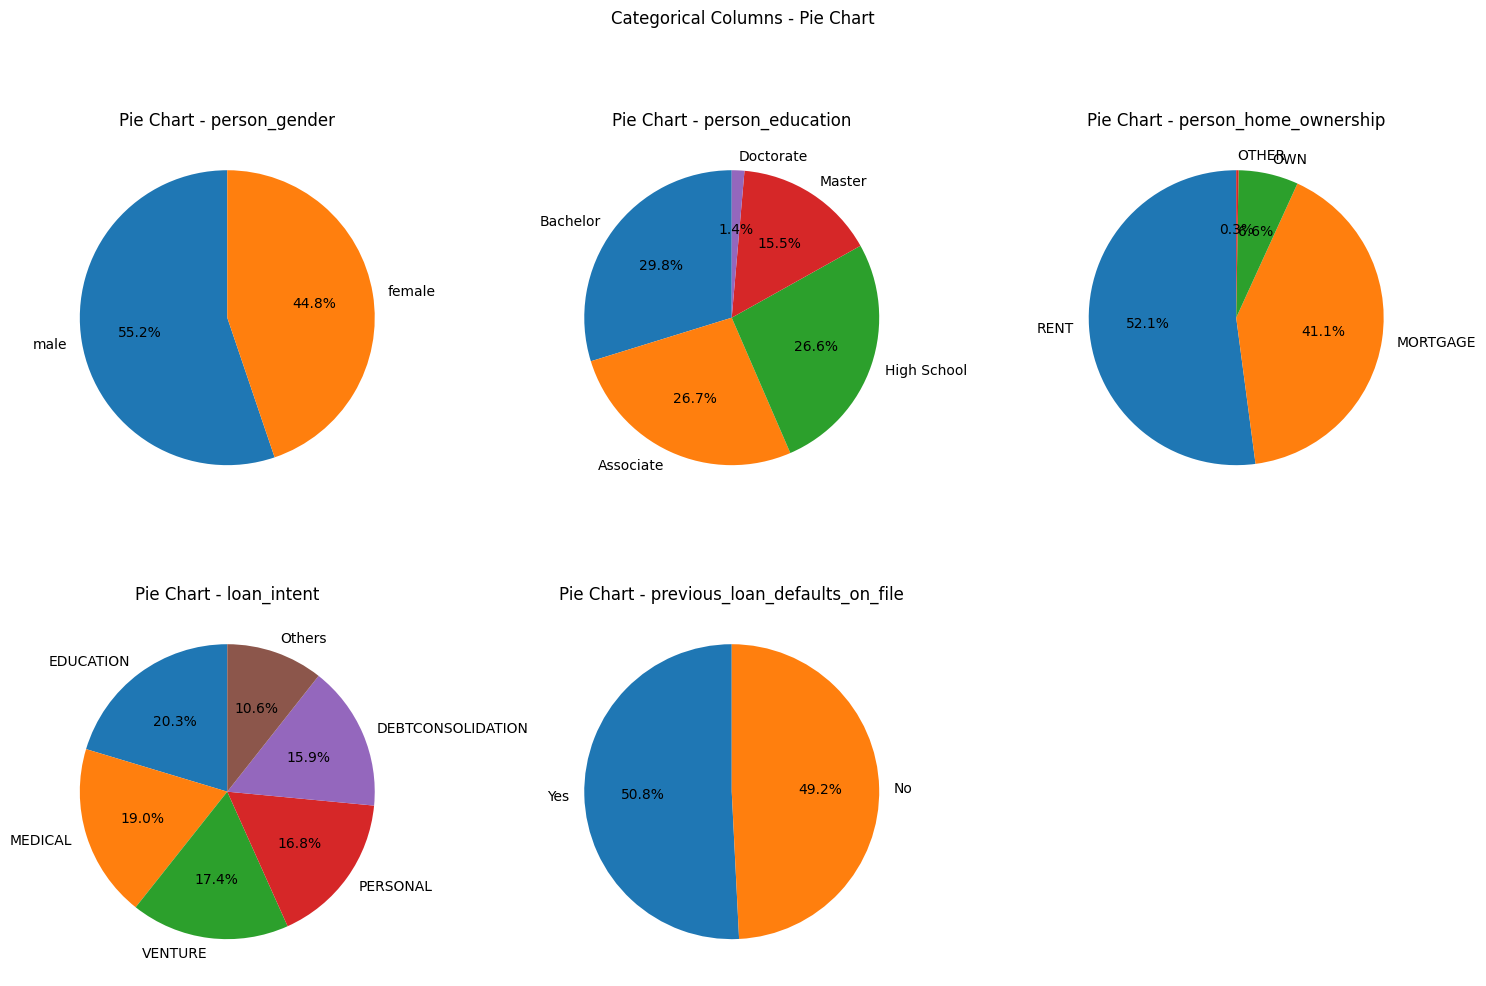

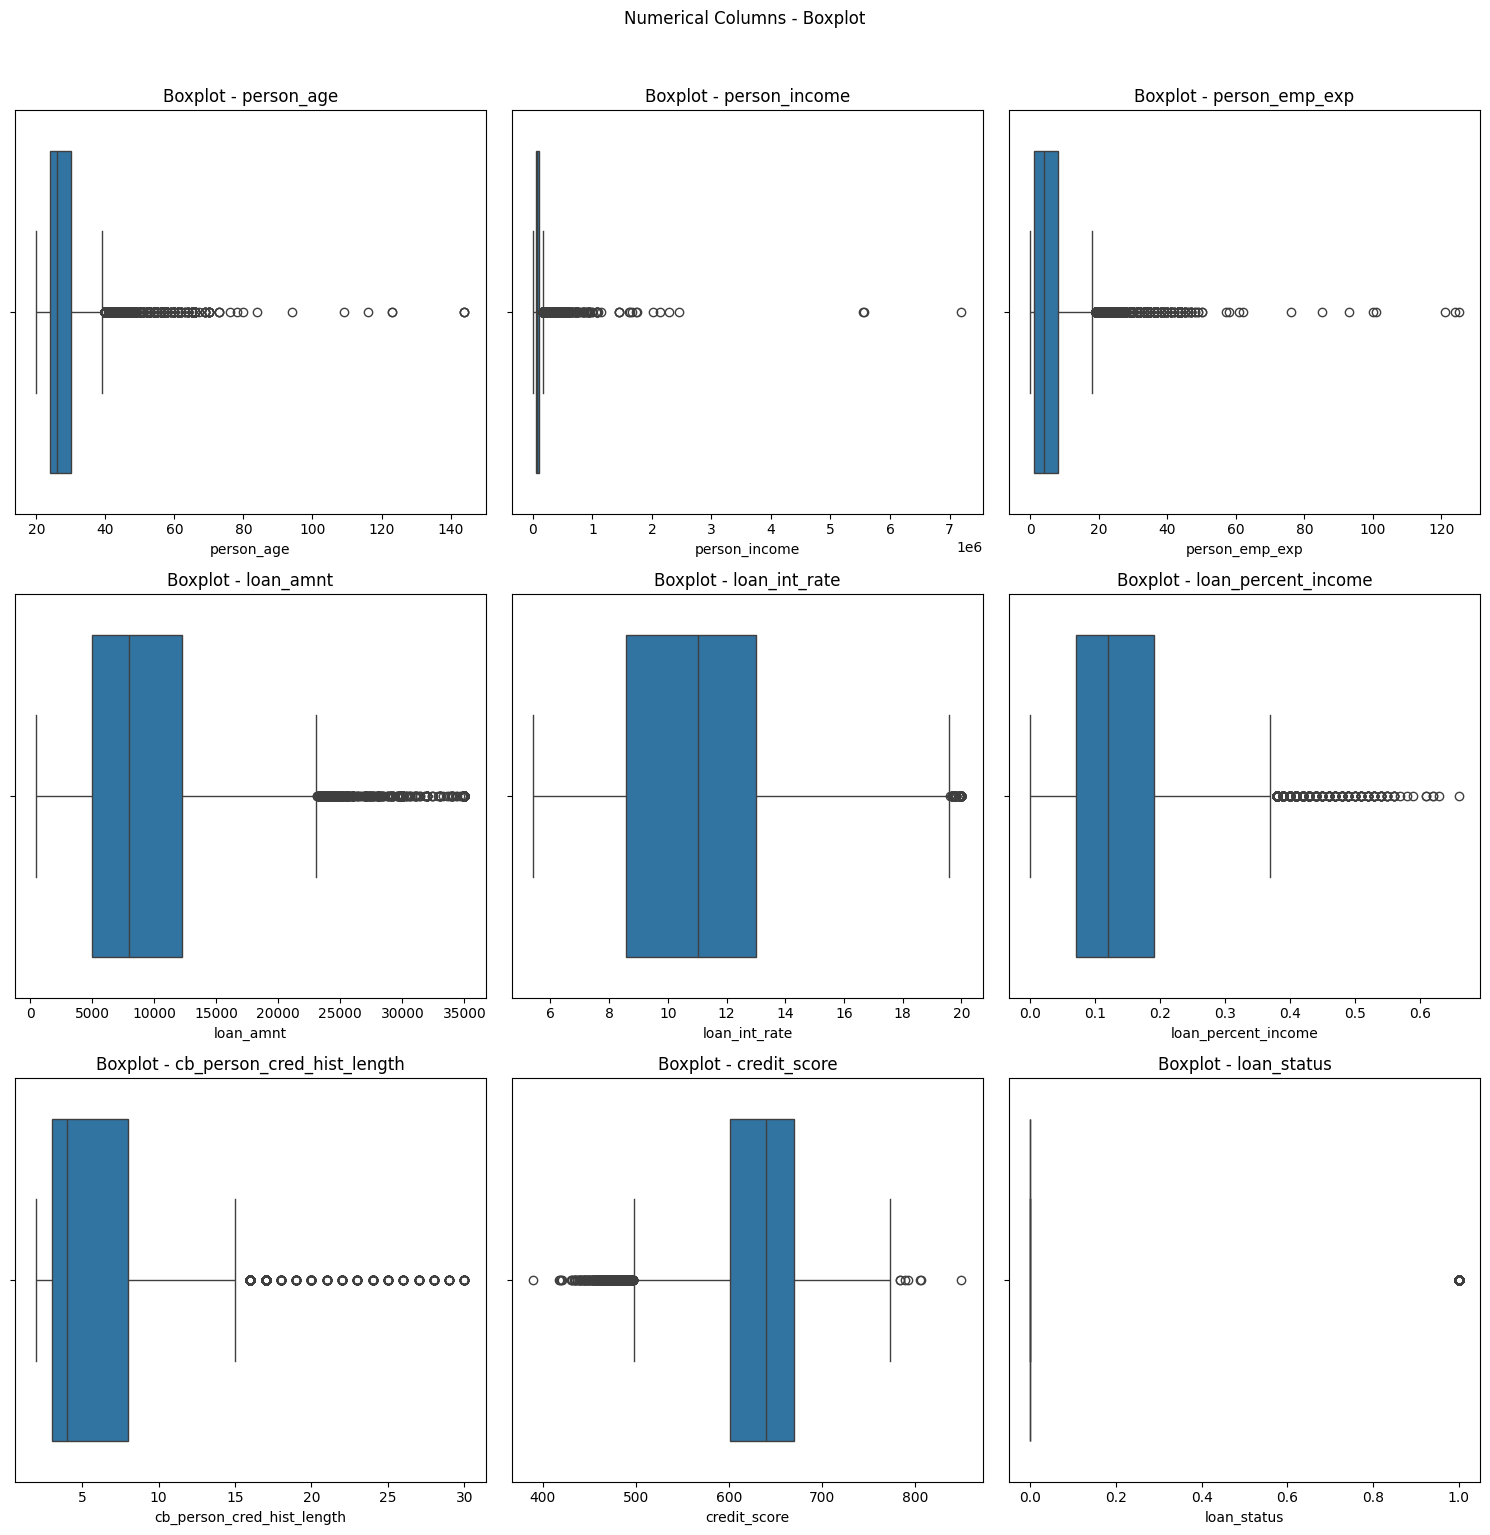

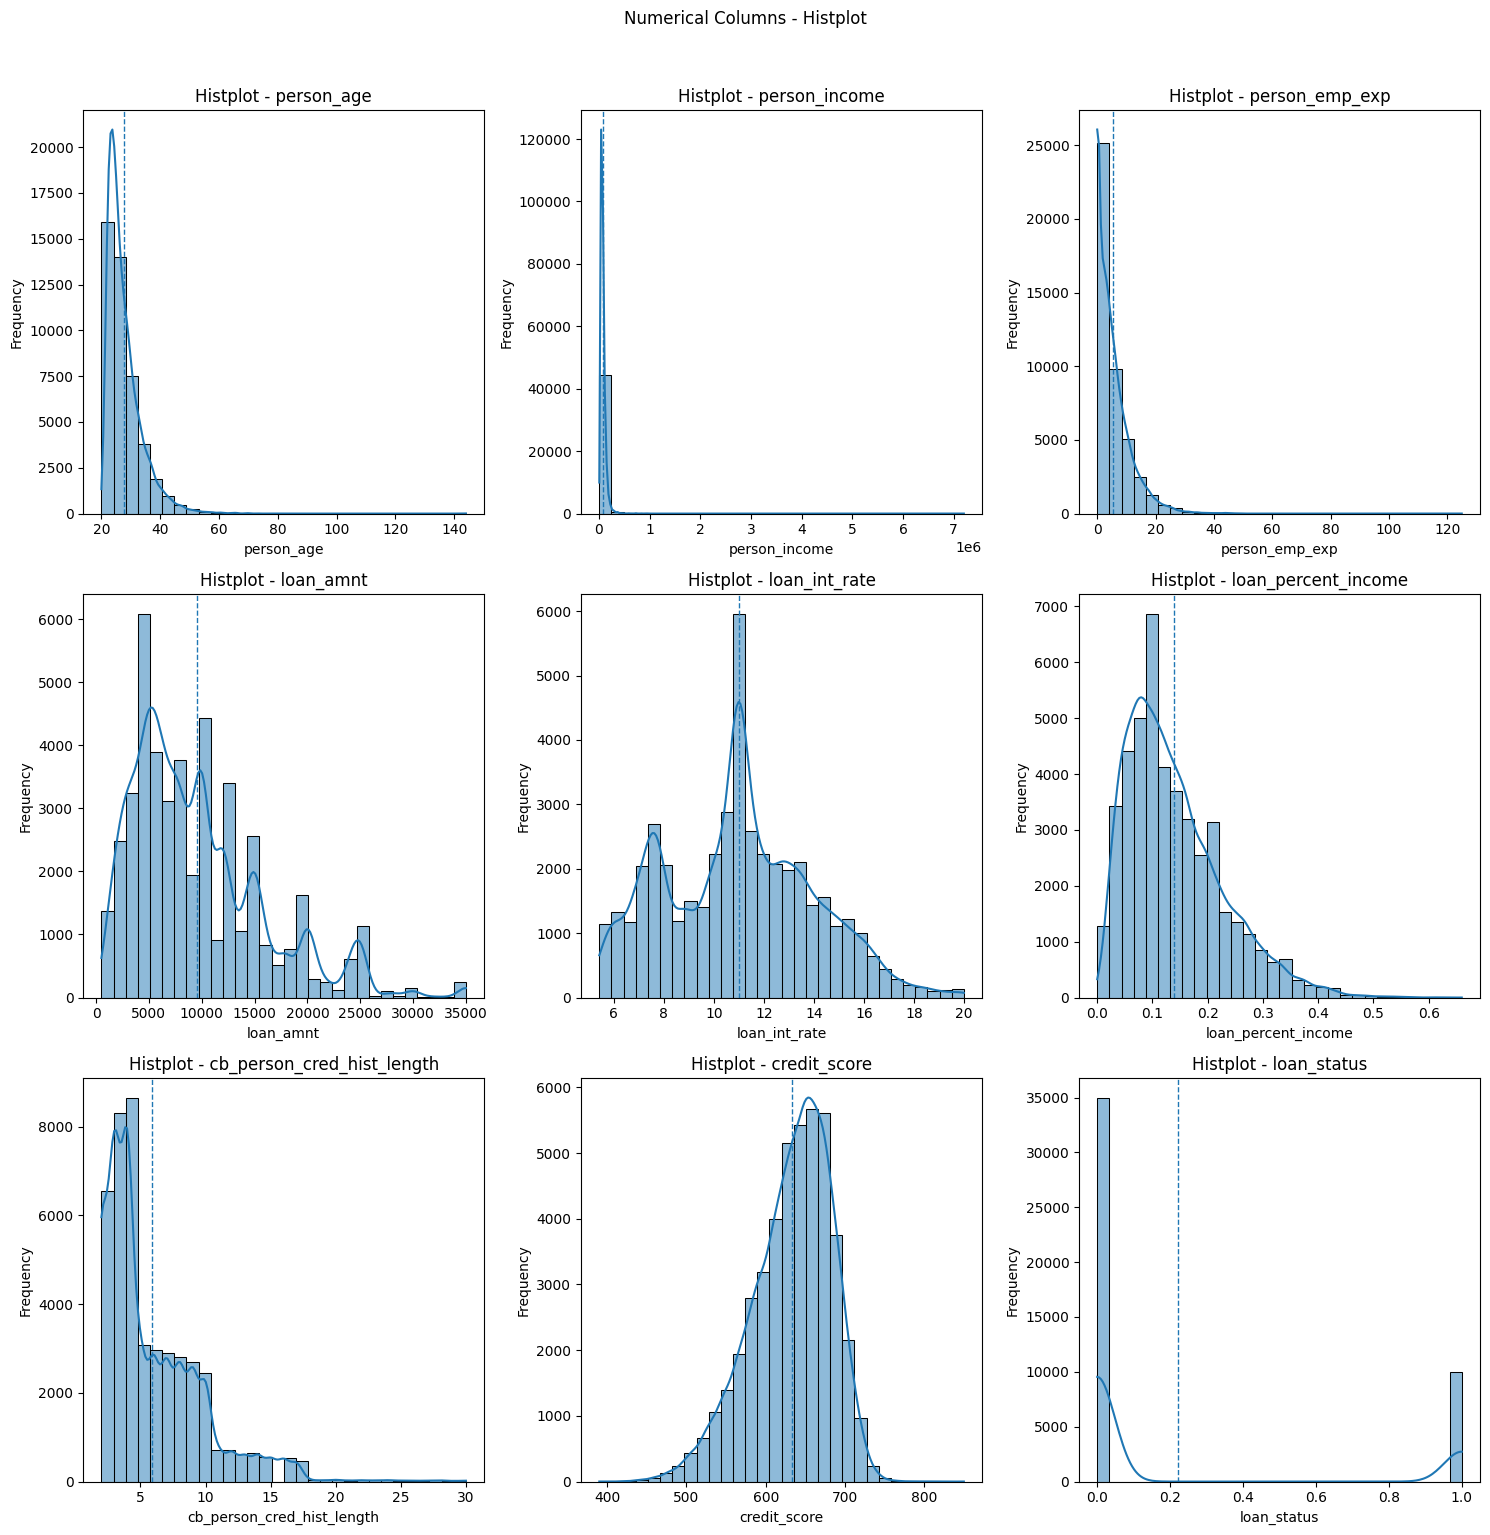

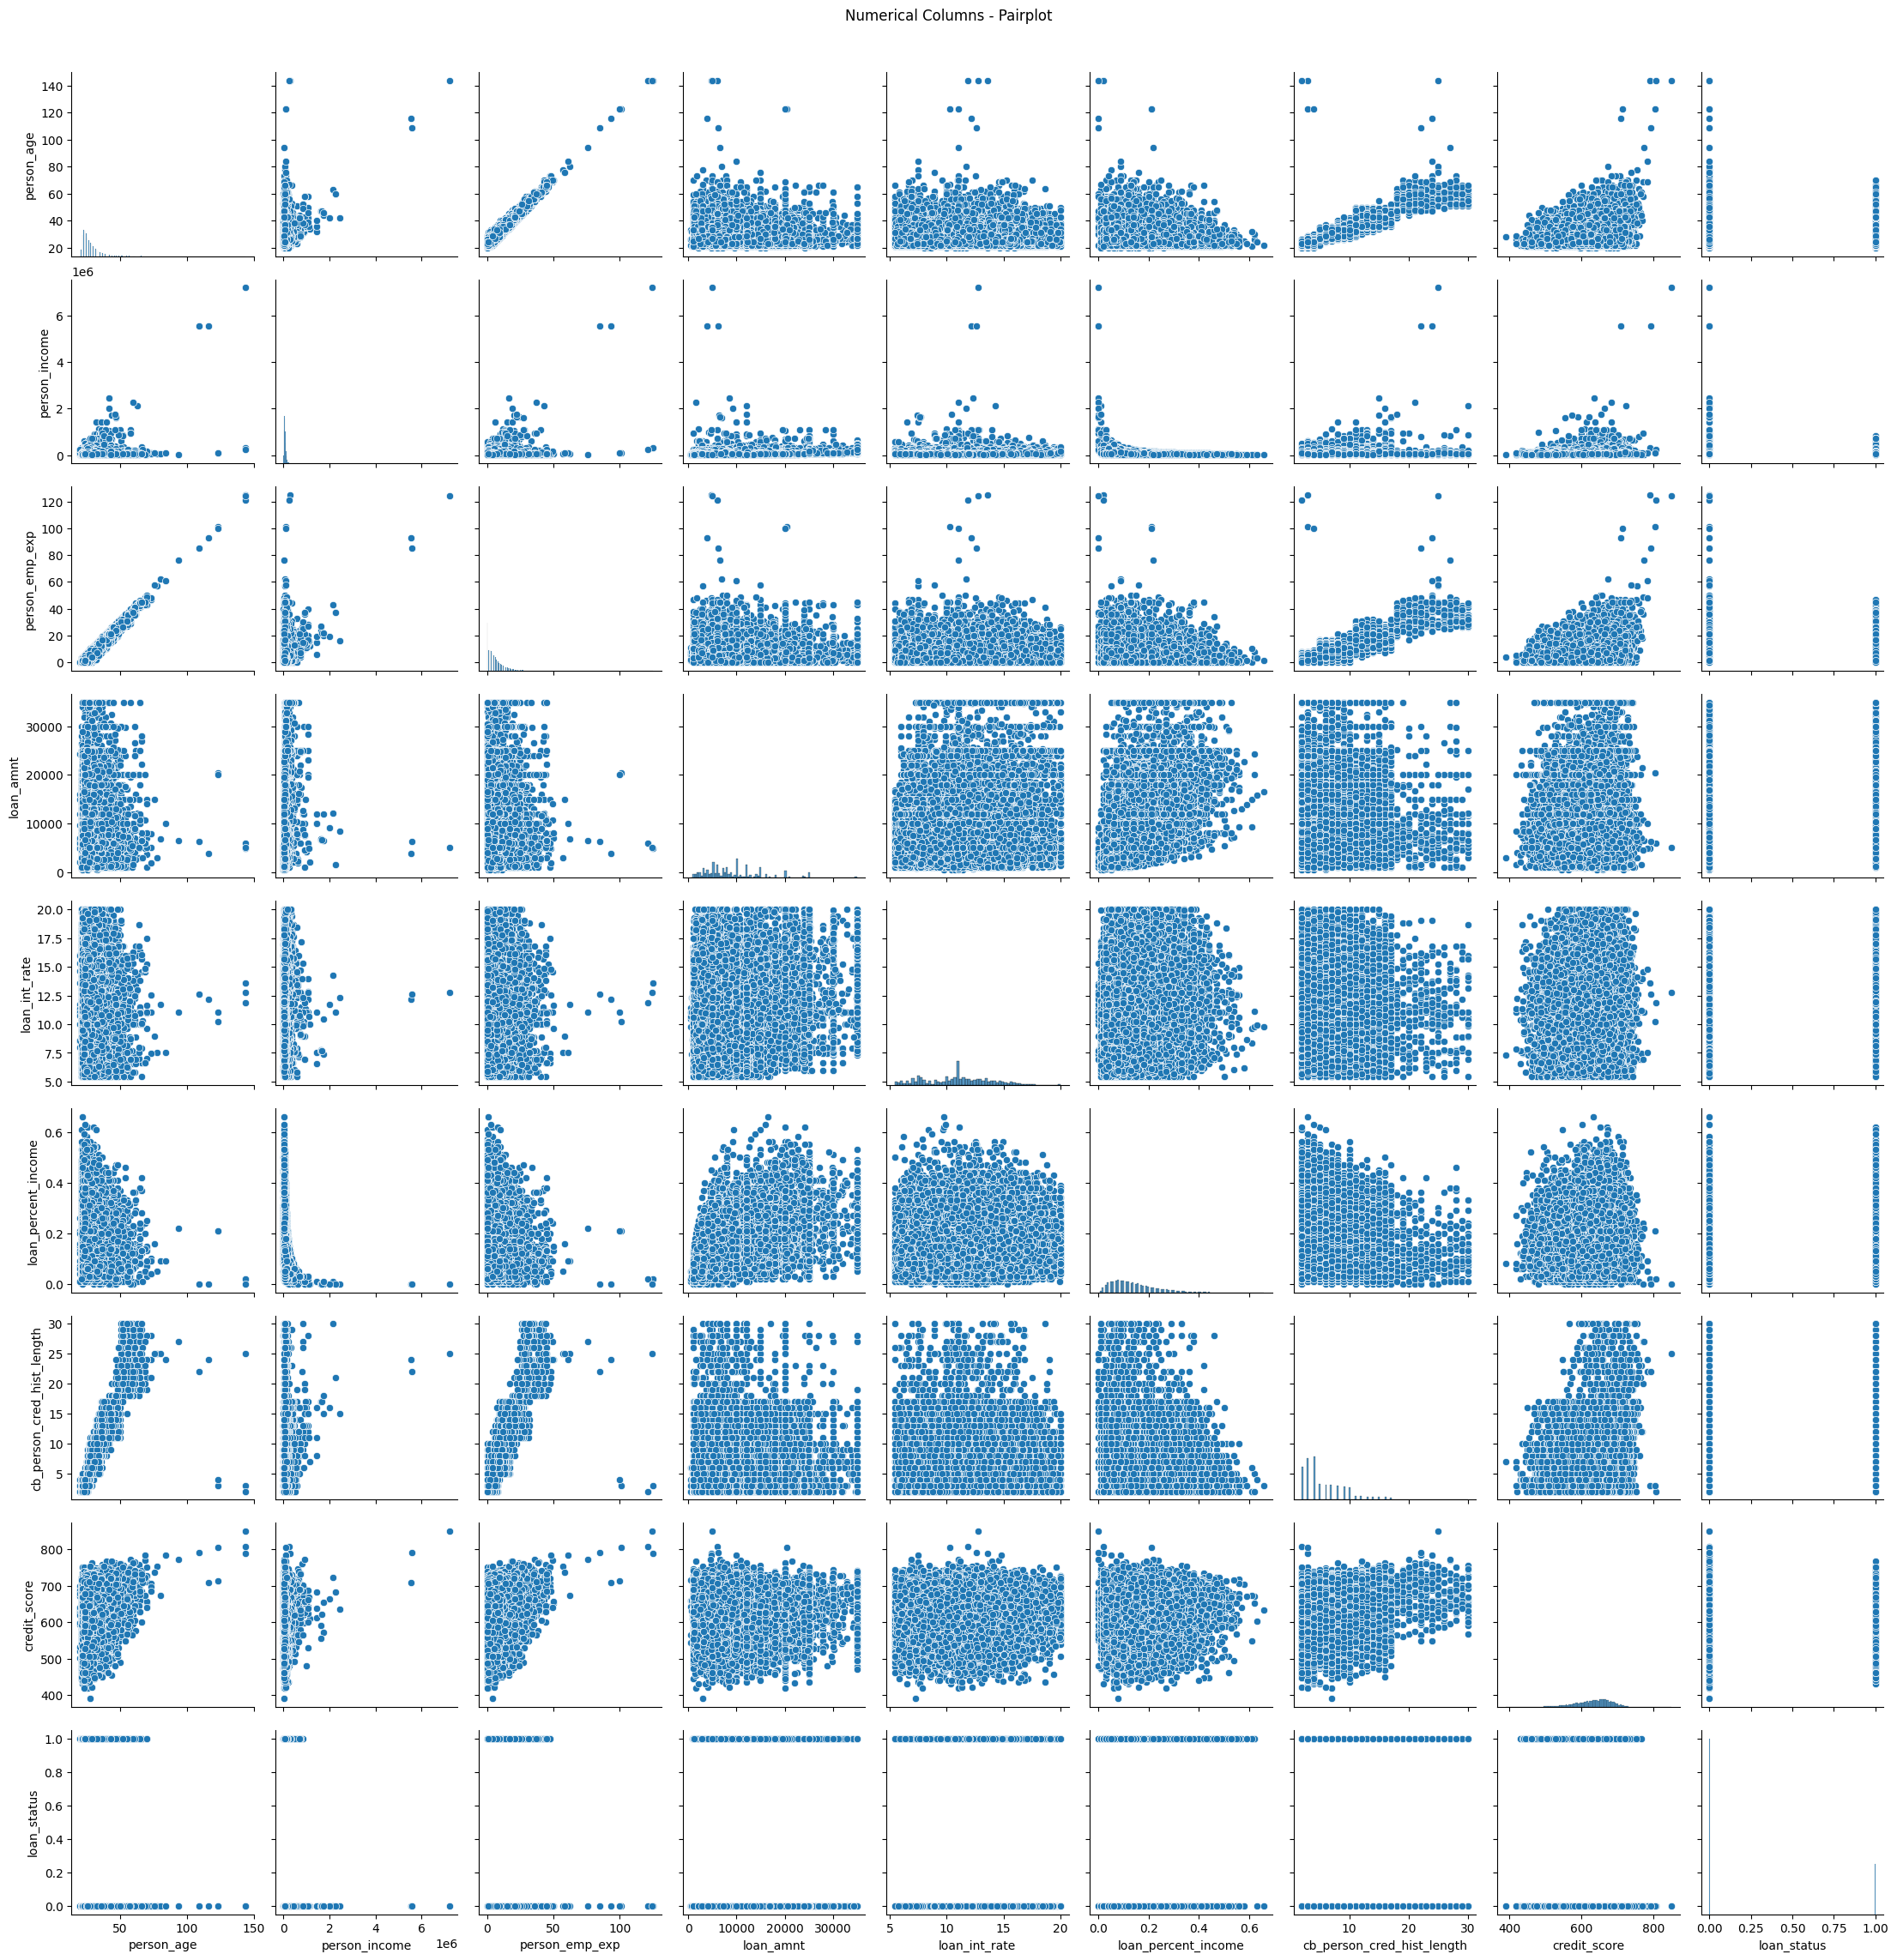

<Figure size 4000x3000 with 0 Axes>

In [9]:
plot_df(df_og)

### Conclusion

#### Pie Chart:
- There are 55% males and 45% females meaning data is very balanced in the gender feature.
- Most people only have upto bachelore degree with less than 1% people having doctorate.
- Most people are living on rent
- Highest amount of loans are for Education.
- 51% of people have failed to pay loan on time.

#### Box Plot:
- Every single one of our features have a lot of outliers, and since our data is very large, we can easily drop these outliers.

#### Hist Plot:
- only interest rate is even close to symmetrical, other features are mostly right or left skewed so we will have to normalise the data.

#### Pair Plot:
- Age and Experience is highly correalated which is obvious.
- Other than that, there doesn't seem too much correlation between each other.

## Target Feature Analysis - loan_status

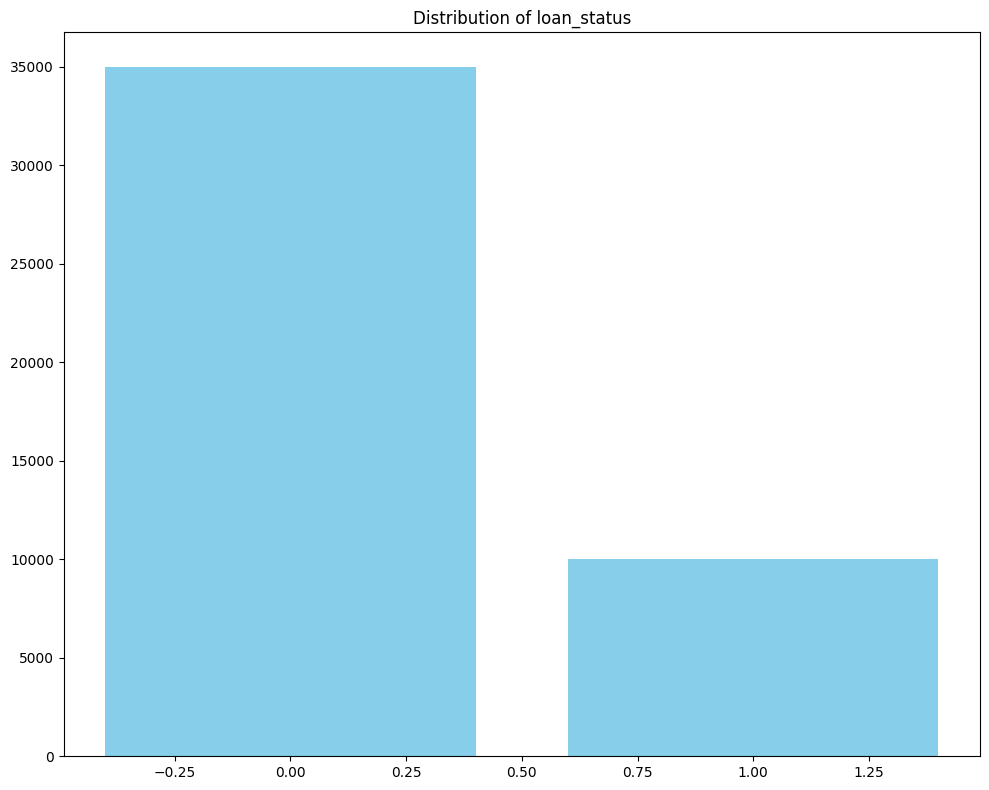

In [10]:
target_feature = "loan_status"

values = df_og[target_feature].value_counts()

plt.figure(figsize=(10, 8))

plt.title(f"Distribution of {target_feature}")
plt.bar(values.index, values, color="skyblue")

plt.tight_layout()
plt.show()

Out of the 45,000 rows: 10,000 are loan approved and 35,000 are loan not approved.

## Feature Selection

In [11]:
X = df_og.drop(target_feature, axis=1)
y = df_og[target_feature]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (45000, 13)
y Shape: (45000,)


## Train - Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify=y, random_state=42
)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (36000, 13)
y_train Shape: (36000,)
X_test Shape: (9000, 13)
y_test Shape: (9000,)


In [13]:
categorical_features = X.select_dtypes(include="object").columns
numeric_features = X.select_dtypes(include="number").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (36000, 27)
X_test_processed shape: (9000, 27)


## ANN

### Making the ANN

In [14]:
model = keras.Sequential([
    Dense(64, activation="relu", input_shape=(27,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["recall", "accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

### Fitting the ANN

In [15]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=20,
    batch_size=2048,
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5823 - loss: 0.6693 - recall: 0.3084 - val_accuracy: 0.7782 - val_loss: 0.5264 - val_recall: 0.0135
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7856 - loss: 0.4697 - recall: 0.0404 - val_accuracy: 0.8011 - val_loss: 0.4196 - val_recall: 0.1175
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8334 - loss: 0.3796 - recall: 0.2980 - val_accuracy: 0.8613 - val_loss: 0.3427 - val_recall: 0.4725
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8722 - loss: 0.3151 - recall: 0.5543 - val_accuracy: 0.8826 - val_loss: 0.2884 - val_recall: 0.6260
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8845 - loss: 0.2725 - recall: 0.6678 - val_accuracy: 0.8922 - val_loss: 0.2557 - val_recall: 0.6975
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8920 - loss: 0.2473 - recall: 0.7184 - val_accuracy: 0.8979 - val_loss: 0.2369 - val_recall: 0.7350
Epoch 7/20
18/18

### Evaluating the ANN

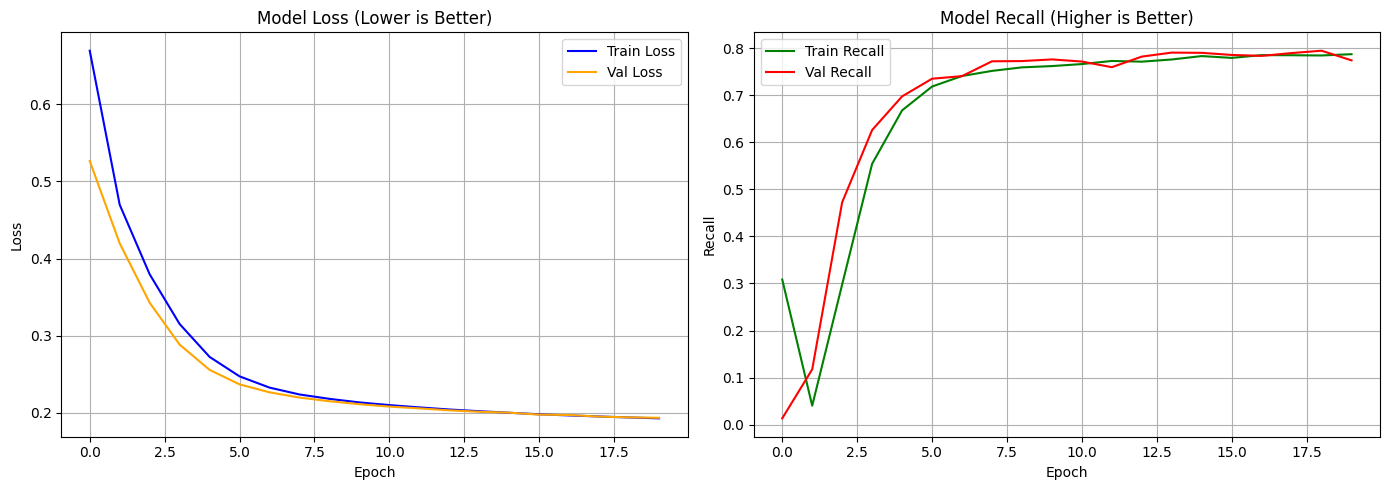

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- GRAPH 1: LOSS ---
ax1.plot(history.history["loss"], label="Train Loss", color="blue")
ax1.plot(history.history["val_loss"], label="Val Loss", color="orange")
ax1.set_title("Model Loss (Lower is Better)")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True)

# --- GRAPH 2: METRICS ---
metric_key = "recall" if "recall" in history.history else "recall_1"

if metric_key in history.history:
    ax2.plot(history.history[metric_key], label="Train Recall", color="green")
    ax2.plot(history.history[f"val_{metric_key}"], label="Val Recall", color="red")
    ax2.set_title("Model Recall (Higher is Better)")
    ax2.set_ylabel("Recall")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    ax2.grid(True)
else:
    print(f"Metric '{metric_key}' not found in history. Keys: {history.history.keys()}")

plt.tight_layout()
plt.show()

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7000
           1       0.84      0.77      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.87      0.88      9000
weighted avg       0.91      0.92      0.91      9000



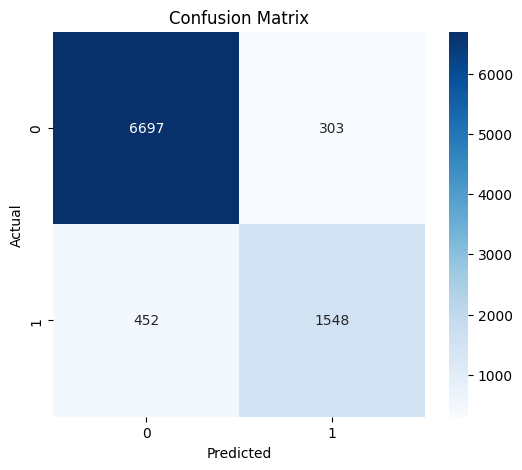

In [17]:
# 1. Get raw probabilities (outputs between 0 and 1)
y_pred_probs = model.predict(X_test_processed)

# 2. Convert probabilities to classes (0 or 1)
# We use 0.5 as the threshold: anything above 50% is a "1"
y_pred_classes = (y_pred_probs > 0.5).astype("int32")

# 3. Print a detailed report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes))

# 4. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Conclusion

- Our Loss Graph shows us that at 13th epoch, we get our best model
- Confusion Matrix:
  - True Negative: 6694, the Human Manager and our model both agreed to not give the loan
  - True Positive: 1544, the Human Manager and our model both agreed to give the loan
  - False Negative: 456, the Human Manager said yes but our model said no to the loan
  - False Positive: 306, the Human Manager said no but our model said yes to the loan

- Overall Alignment: 92%
  - Precision: 83%, when AI says "Approve this loan", it agrees with the Human Manager 83% of the time
  - Recall: 77%, when AI says "Do not Approve this loan", it agrees with the Human Manager 77% of the time, losing 22% of potential customers.

In [18]:
import joblib

# Save the column transformer
joblib.dump(preprocessor, "preprocessor.joblib")
print("Preprocessor saved as 'preprocessor.joblib'")

# Save the model architecture and weights
model.save("loan_approval_model.keras")
print("Model saved as 'loan_approval_model.keras'")

Preprocessor saved as 'preprocessor.joblib'
Model saved as 'loan_approval_model.keras'


## Prediction

Now that we have our model saved, we can just load it in and run this one cell or copy this cell into a predict.py to predict on real time data, or using an API and integrating it into a frontend we can turn this into a fully fledged application.

In [19]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import joblib
import pandas as pd
import numpy as np

# 1. Load the artifacts
print("Loading model and preprocessor...")
try:
    loaded_model = keras.models.load_model("loan_approval_model.keras")
    loaded_preprocessor = joblib.load("preprocessor.joblib")
except Exception as e:
    print(f"Error loading files: {e}")
    # Stop here if files aren't found
    exit()

# 2. Create a "Fake Person" to test
new_applicant = pd.DataFrame(
    [
        {
            # --- EXISTING FIELDS ---
            "person_age": 25,
            "person_income": 55000,
            "person_home_ownership": "RENT",
            "loan_intent": "EDUCATION",
            "loan_grade": "B",
            "loan_amnt": 12000,
            "loan_int_rate": 11.5,
            "loan_percent_income": 0.22,
            "cb_person_cred_hist_length": 3,
            "person_emp_exp": 3,
            "person_education": "Bachelor",
            "credit_score": 650,
            "previous_loan_defaults_on_file": "No",
            "person_gender": "Female",
            "cb_person_default_on_file": "N",
        }
    ]
)

# 3. Preprocess
print("Transforming data...")
try:
    X_new = loaded_preprocessor.transform(new_applicant)

    # 4. Predict
    if hasattr(X_new, "toarray"):
        X_new = X_new.toarray()

    prediction = loaded_model.predict(X_new)
    probability = prediction[0][0]

    print(f"\n--- Prediction Result ---")
    print(f"Approval Probability: {probability:.4f}")
    print(f"Final Decision: {'APPROVED' if probability > 0.5 else 'REJECTED'}")

except ValueError as e:
    print(f"\nValue Error: {e}")
    print(
        "Tip: Double check that the column names in 'new_applicant' match your X_train exactly."
    )

Loading model and preprocessor...
Transforming data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- Prediction Result ---
Approval Probability: 0.7508
Final Decision: APPROVED
